### Logic flow

per patient:
* spikes & triggers come from two devices on one synced clock
    * spikes: OSort ran on the ns6 -> spike time 0 = ns6 recording start
    * triggers: task codes land in the NSP nev, stamped on that same clock
    * so aligned_time = trigger time - ns6 recording start puts triggers on the spike clock
* the trigger stream can hold trials psychopy never logged (practice blocks, aborted test trials) -> keep the last n_beh_trials trigger trials
* pair trials: psychopy row i (played order) = i-th trigger trial
* alignment check: population PSTH locked to stim onset shows an evoked bump only on the spike clock (old block1 anchor: flat)
* per epoch: cut each neuron's spikes & smoothed FRs (Hz) in a window around the epoch's start trigger
* reorder trials to trial_key order -> one shared trial axis across patients

stack & save:
* stack patients along the neuron axis -> pseudopopulation
* save per epoch: spikes (trials, all_neurs), FRs (trials, all_neurs, bins; raw - norm downstream via flag), trial_mean_FRs (trials, all_neurs), bin_centers; plus all_neurs_info_df (patient, region, stacked column idx)
* epoch sanity: grand-mean FR modulates around each epoch's start

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from neo.io import BlackrockIO
import scipy.io as sio, h5py

In [2]:
pseudopop_dir = '../../outputs/processed_data/pseudopop'; os.makedirs(pseudopop_dir, exist_ok=True)
processed_dir = '../../outputs/processed_data'  # per-patient inputs (neurs_info_df.parquet)

all_beh_trials_df = pd.read_csv('../../data/psychopy/all_beh_trials_df.csv')
patients = all_beh_trials_df.loc[all_beh_trials_df['eligibility'] == 'neuronal', 'subj'].unique(); print(f'neural patients: {patients}')

size, dt = .02, .01 # smoothing params

# set epoch prestarts and durations (xlims)
epochs = ['baseline', 'stim', 'delay', 'response', 'feedback']; epoch_prestarts, epoch_durs = {}, {}

for epoch in epochs:

    # where to start x-axis
    if epoch == 'baseline': epoch_prestarts[epoch] = -0
    elif epoch == 'response': epoch_prestarts[epoch] = -1 # 1s before response submitted
    else: epoch_prestarts[epoch] = -.25

    # plot duration
    if epoch == 'delay': epoch_durs[epoch] = 1.5
    elif epoch == 'response': epoch_durs[epoch] = 0 # 0s after response submitted
    else: epoch_durs[epoch] = 1

print(f'prestarts: {epoch_prestarts}\ndurations: {epoch_durs}')

neural patients: [2512. 2518. 2521. 2522. 2605.]
prestarts: {'baseline': 0, 'stim': -0.25, 'delay': -0.25, 'response': -1, 'feedback': -0.25}
durations: {'baseline': 1, 'stim': 1, 'delay': 1.5, 'response': 0, 'feedback': 1}


### helpers

In [3]:
def get_pt_trigs(patient):
    ''' digital trigger stream from the nev, on the spike clock: aligned_time zero = first sample of the sorted ns6 '''
    # OSort spike times count from the ns6's first sample, and the nev shares the synced (PTP) clock,
    # so the anchor is the ns6 recording start - NOT the block1 trigger (the task starts 36-107s into the recording)
    nev_files = glob.glob(f'../../data/20{int(patient)}/raw/*.nev') + glob.glob(f'../../data/20{int(patient)}/*.nev')
    assert nev_files, f'pt{int(patient)}: no nev file with triggers'
    real_nevs = [f for f in nev_files if open(f, 'rb').read(8) in (b'NEURALEV', b'BREVENTS')]

    if real_nevs:  # genuine Blackrock nev: neo puts event times on the synced clock in seconds
        io = BlackrockIO(real_nevs[0]); seg = io.read_block(lazy=False).segments[0]
        dig_ev = [ev for ev in seg.events if "digital" in ev.name.lower()][0]
        trigger_codes, trigger_times = dig_ev.labels.astype(int), dig_ev.times.magnitude
    else:  # DI's 2026 uploads: openNEV export saved as .mat but named .nev; raw TimeStamp is PTP nanoseconds
        nev_mat = sio.loadmat(nev_files[0], squeeze_me=True, struct_as_record=False)
        dig_io = nev_mat['NEV'].Data.SerialDigitalIO
        trigger_codes, trigger_times = np.asarray(dig_io.UnparsedData).astype(int), np.asarray(dig_io.TimeStamp).astype(float) / 1e9
    assert len(trigger_codes), f'pt{int(patient)}: nev has zero digital trigger events'

    # ns6 recording start on the same clock; a paused/multi-segment recording would break the spike-time anchor
    ns6_files = sorted(glob.glob(f'../../data/20{int(patient)}/raw/*.ns6'))
    if ns6_files:
        blk = BlackrockIO(ns6_files[-1]).read_block(lazy=True); assert len(blk.segments) == 1, f'pt{int(patient)}: ns6 has {len(blk.segments)} segments'
        ns6_start = float(blk.segments[0].analogsignals[0].t_start.rescale('s').magnitude)
    else:  # ns6 also an openNSx export: MetaTags.Timestamp is PTP nanoseconds
        ns6_start = float(np.array(h5py.File(glob.glob(f'../../data/20{int(patient)}/raw/*_ns6.mat')[0], 'r')['NSX']['MetaTags']['Timestamp']).ravel()[0]) / 1e9

    code_map = {10:"block started",20:"baseline started",30:"stim started",40:"delay started",50:"task started",51:"marker moved",52:"left pressed",53:"left released",54:"right pressed",55:"right released",56:"response submitted",60:"anticipation started",70:"feedback started",80:"block ended"}

    pt_neur_trigs_df = pd.DataFrame({"trigger_code": trigger_codes, "aligned_time": trigger_times - ns6_start}); pt_neur_trigs_df["event"] = pt_neur_trigs_df["trigger_code"].map(code_map)
    return pt_neur_trigs_df


def get_epoch_spikes_and_FRs(pt_neur_trigs_df, neurs_info_df, epoch, size=size, dt=dt):
    ''' for each trial and neuron, get spike times and smoothed FRs (Hz) in epoch window
        pt_neur_trigs_df: trig times, neurs_info_df: spike times per neur '''

    epoch_prestart, epoch_dur = epoch_prestarts[epoch], epoch_durs[epoch]
    bin_edges = np.arange(epoch_prestart, epoch_dur + dt, dt); bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2; n_bins = len(bin_edges) - 1

    # get epoch start indices & times
    if epoch != 'response': epoch_start_rows = pt_neur_trigs_df[pt_neur_trigs_df['event'] == f'{epoch} started'].index
    # using anticipation started instead of response submitted bc sometimes they dont respond
    else: epoch_start_rows = pt_neur_trigs_df[pt_neur_trigs_df['event'] == 'anticipation started'].index
    epoch_starts = pt_neur_trigs_df.loc[epoch_start_rows, 'aligned_time'].values; n_trials = len(epoch_starts)

    trial_neur_spikes, trial_neur_FRs = np.empty((n_trials, len(neurs_info_df)), dtype=object), np.zeros((n_trials, len(neurs_info_df), n_bins))

    for trial_idx in range(n_trials):
        for neur_idx, (_, neur_row) in enumerate(neurs_info_df.iterrows()):

            trial_epoch_spikes = neur_row['spikes'][(neur_row['spikes'] >= epoch_starts[trial_idx] + epoch_prestart) &
                                                    (neur_row['spikes'] <= epoch_starts[trial_idx] + epoch_dur)]
            trial_epoch_spikes = trial_epoch_spikes - epoch_starts[trial_idx] # align

            # bin and smooth
            counts, _ = np.histogram(trial_epoch_spikes, bins=bin_edges)
            smooth_spike_train = gaussian_filter1d(counts.astype(float), sigma=size/dt, mode='reflect', truncate=3.0)
            smooth_spike_train = smooth_spike_train / dt  # instantaneous FR (Hz): spikes/bin / s/bin

            trial_neur_spikes[trial_idx, neur_idx], trial_neur_FRs[trial_idx, neur_idx, :] = trial_epoch_spikes, smooth_spike_train

    return trial_neur_spikes, trial_neur_FRs, bin_centers


### per patient: triggers on the spike clock, trimmed & paired
* aligned_time from get_pt_trigs -> triggers and spikes share one timeline
* practice/aborted trials precede the task; psychopy logs only the task -> keep the last n_beh_trials trigger trials
* pairing guarantee: after the trim, trigger trials == beh trials (asserted)

In [4]:
pt_neur_trigs_dfs, pt_beh_trials_dfs, pt_neurs_info_dfs, block1_aligned_times = {}, {}, {}, {}
for patient in patients:
    pt_neur_trigs_df = get_pt_trigs(patient)
    pt_beh_trials_df = all_beh_trials_df.loc[all_beh_trials_df['subj'] == patient].sort_values('trial_chronological_idx').reset_index(drop=True)

    # the old (wrong) anchor, kept only for the alignment-check figure below
    block1_aligned_times[patient] = pt_neur_trigs_df.loc[pt_neur_trigs_df['event'] == 'block started', 'aligned_time'].iloc[0]

    # keep the last len(beh) trigger trials; anything earlier is practice or an aborted test trial
    baseline_rows = pt_neur_trigs_df.index[pt_neur_trigs_df['event'] == 'baseline started']
    assert len(baseline_rows) >= len(pt_beh_trials_df), f'pt{int(patient)}: {len(baseline_rows)} trigger trials < {len(pt_beh_trials_df)} beh trials'
    n_extra_trials = len(baseline_rows) - len(pt_beh_trials_df)
    if n_extra_trials: pt_neur_trigs_df = pt_neur_trigs_df.loc[baseline_rows[n_extra_trials]:].reset_index(drop=True)
    assert (pt_neur_trigs_df['event'] == 'baseline started').sum() == len(pt_beh_trials_df)

    pt_neur_trigs_dfs[patient], pt_beh_trials_dfs[patient] = pt_neur_trigs_df, pt_beh_trials_df
    pt_neurs_info_dfs[patient] = pd.read_parquet(f'{processed_dir}/20{int(patient)}/neurs_info_df.parquet')
    pt_neur_trigs_df.to_parquet(f'{processed_dir}/20{int(patient)}/neur_trigs_df.parquet')
    print(f'pt{int(patient)}: {len(baseline_rows)} trigger trials, {len(pt_beh_trials_df)} beh trials, dropped {n_extra_trials}; {len(pt_neurs_info_dfs[patient])} neurons')

pt2512: 241 trigger trials, 240 beh trials, dropped 1; 18 neurons


pt2518: 240 trigger trials, 240 beh trials, dropped 0; 32 neurons


pt2521: 240 trigger trials, 240 beh trials, dropped 0; 14 neurons


pt2522: 240 trigger trials, 240 beh trials, dropped 0; 7 neurons
pt2605: 252 trigger trials, 240 beh trials, dropped 12; 10 neurons


### alignment check
* on the spike clock, the population responds ~100-300ms after stim onset; the old block1 anchor reads spikes 36-107s away -> flat

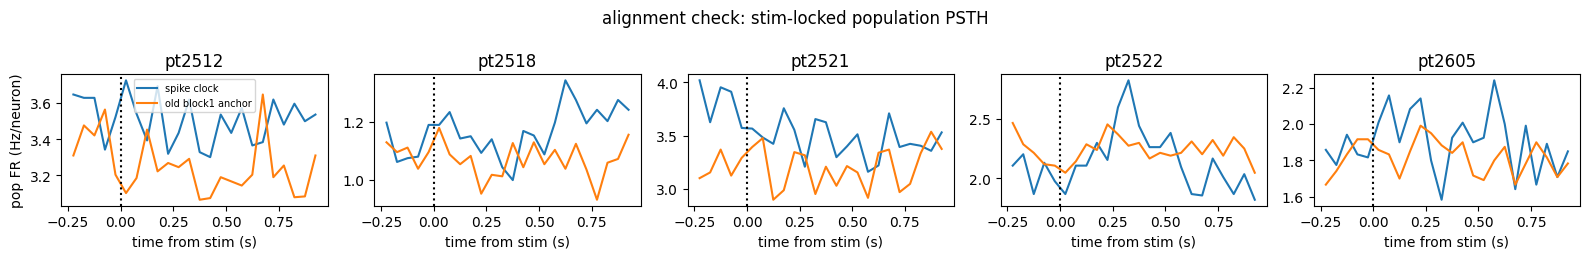

In [5]:
fig, axs = plt.subplots(1, len(patients), figsize=(16, 2.6), sharex=True)
fig.suptitle('alignment check: stim-locked population PSTH')
check_bin_edges = np.arange(-0.25, 1.0, 0.05); check_bin_centers = (check_bin_edges[:-1] + check_bin_edges[1:]) / 2
for ax, patient in zip(axs, patients):
    pt_spikes = np.sort(np.concatenate(pt_neurs_info_dfs[patient]['spikes'].values))
    stim_starts = pt_neur_trigs_dfs[patient].loc[pt_neur_trigs_dfs[patient]['event'] == 'stim started', 'aligned_time'].values
    for label, anchor_offset in [('spike clock', 0), ('old block1 anchor', block1_aligned_times[patient])]:
        psth = np.stack([np.histogram(pt_spikes - st, bins=check_bin_edges)[0] for st in stim_starts - anchor_offset]).mean(axis=0)
        ax.plot(check_bin_centers, psth / 0.05 / len(pt_neurs_info_dfs[patient]), label=label)
    ax.axvline(0, color='k', ls=':'); ax.set(title=f'pt{int(patient)}', xlabel='time from stim (s)')
axs[0].set(ylabel='pop FR (Hz/neuron)'); axs[0].legend(fontsize=7); plt.tight_layout()

### per epoch: extract, then one shared trial axis
* cut spikes & smoothed FRs per (trial, neuron) around each epoch's start trigger; every epoch must yield exactly n_beh_trials (asserted)
* played order differs across patients (blocks shuffled) -> reorder to trial_key; all patients must then carry the identical trial sequence (asserted)

In [6]:
pt_epoch_data = {}
for patient in patients:
    pt_epoch_data[patient] = {epoch: get_epoch_spikes_and_FRs(pt_neur_trigs_dfs[patient], pt_neurs_info_dfs[patient], epoch) for epoch in epochs}
    for epoch in epochs: assert pt_epoch_data[patient][epoch][0].shape[0] == len(pt_beh_trials_dfs[patient]), f'pt{int(patient)} {epoch}: trial count mismatch'

    # played order differs across patients (blocks shuffled), so put trials in trial_key order -> one shared trial axis for stacking
    trial_key_order = np.argsort(pt_beh_trials_dfs[patient]['trial_key'].values)
    pt_epoch_data[patient] = {epoch: (spikes[trial_key_order], FRs[trial_key_order], bins) for epoch, (spikes, FRs, bins) in pt_epoch_data[patient].items()}
    pt_beh_trials_dfs[patient] = pt_beh_trials_dfs[patient].iloc[trial_key_order].reset_index(drop=True)
    print(f'pt{int(patient)}: {pt_epoch_data[patient]["stim"][1].shape} (trials, neurons, bins) per epoch')

# every patient must now carry the identical trial sequence, or the neuron-axis stack is meaningless
for patient in patients[1:]:
    assert (pt_beh_trials_dfs[patient]['trial_key'].values == pt_beh_trials_dfs[patients[0]]['trial_key'].values).all()

pt2512: (240, 18, 125) (trials, neurons, bins) per epoch


pt2518: (240, 32, 125) (trials, neurons, bins) per epoch


pt2521: (240, 14, 125) (trials, neurons, bins) per epoch


pt2522: (240, 7, 125) (trials, neurons, bins) per epoch


pt2605: (240, 10, 125) (trials, neurons, bins) per epoch


### stack patients along the neuron axis -> pseudopopulation; save

In [7]:
# neuron metadata: which stacked column is which neuron
all_neurs_info_df = pd.concat(list(pt_neurs_info_dfs.values()), ignore_index=True)
all_neurs_info_df['pop_neur_idx'] = np.concatenate([np.arange(len(df)) for df in pt_neurs_info_dfs.values()])  # column within own patient
all_neurs_info_df['col_idx'] = np.arange(len(all_neurs_info_df))                                      # column in stacked matrices
all_neurs_info_df.to_parquet(f'{pseudopop_dir}/all_neurs_info_df.parquet')
print(f'all_neurs_info_df: {len(all_neurs_info_df)} neurons across {all_neurs_info_df["patient"].nunique()} patients')
all_neurs_info_df[['patient', 'chanID', 'unitID', 'region', 'pop_neur_idx', 'col_idx']].head()

all_neurs_info_df: 81 neurons across 5 patients


,patient,chanID,unitID,region,pop_neur_idx,col_idx
0,2512,97,612,mLOFC1,0,0
1,2512,98,1583,mLOFC2,1,1
2,2512,99,703,mLOFC3,2,2
3,2512,101,952,mLOFC5,3,3
4,2512,102,2460,mLOFC6,4,4


In [8]:
epoch_FRs, epoch_bins = {}, {}
for epoch in epochs:
    os.makedirs(f'{pseudopop_dir}/{epoch}', exist_ok=True)
    spikes = np.hstack([pt_epoch_data[pt][epoch][0] for pt in patients])                  # (trials, all_neurs) spike times
    FRs    = np.concatenate([pt_epoch_data[pt][epoch][1] for pt in patients], axis=1)     # (trials, all_neurs, bins)
    bins   = pt_epoch_data[patients[0]][epoch][2]
    trial_mean_FRs = FRs.mean(axis=2)  # scalar FR per (trial, neuron); feeds tuning heatmaps & decoding

    np.save(f'{pseudopop_dir}/{epoch}/spikes.npy', spikes, allow_pickle=True)
    np.save(f'{pseudopop_dir}/{epoch}/FRs.npy', FRs, allow_pickle=True)
    np.save(f'{pseudopop_dir}/{epoch}/trial_mean_FRs.npy', trial_mean_FRs, allow_pickle=True)
    np.save(f'{pseudopop_dir}/{epoch}/bin_centers.npy', bins, allow_pickle=True)
    epoch_FRs[epoch], epoch_bins[epoch] = FRs, bins
    print(f'{epoch}: spikes {spikes.shape}, FRs {FRs.shape}, trial_mean_FRs {trial_mean_FRs.shape}, bins {bins.shape}')

# no trial table saved: rows are trial_key order, so downstream just sorts all_beh_trials_df.csv by trial_key

baseline: spikes (240, 81), FRs (240, 81, 100), trial_mean_FRs (240, 81), bins (100,)
stim: spikes (240, 81), FRs (240, 81, 125), trial_mean_FRs (240, 81), bins (125,)
delay: spikes (240, 81), FRs (240, 81, 175), trial_mean_FRs (240, 81), bins (175,)


response: spikes (240, 81), FRs (240, 81, 100), trial_mean_FRs (240, 81), bins (100,)
feedback: spikes (240, 81), FRs (240, 81, 125), trial_mean_FRs (240, 81), bins (125,)


### epoch sanity
* each epoch's grand-mean FR should modulate around its start trigger (t=0)

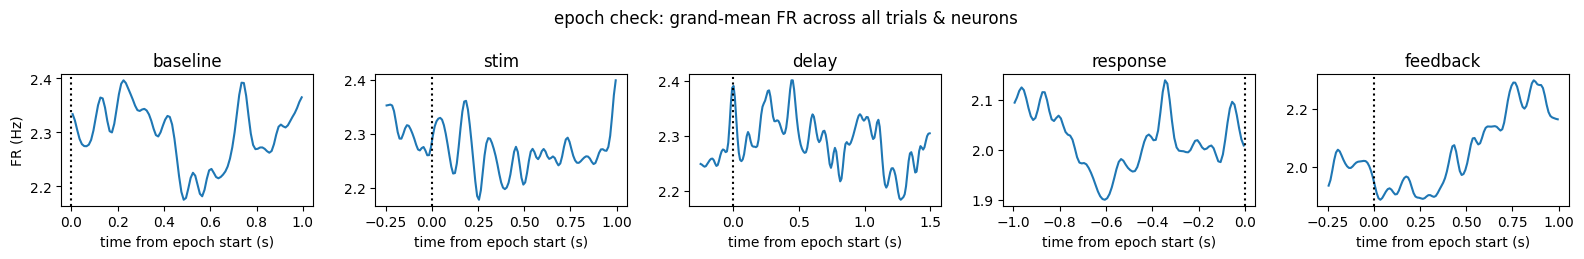

In [9]:
fig, axs = plt.subplots(1, len(epochs), figsize=(16, 2.6))
fig.suptitle('epoch check: grand-mean FR across all trials & neurons')
for ax, epoch in zip(axs, epochs):
    ax.plot(epoch_bins[epoch], epoch_FRs[epoch].mean(axis=(0, 1)))
    ax.axvline(0, color='k', ls=':'); ax.set(title=epoch, xlabel='time from epoch start (s)')
axs[0].set(ylabel='FR (Hz)'); plt.tight_layout()